<a href="https://colab.research.google.com/github/rudmaxx/Melbourne-housing-DTA/blob/main/notebooks/Example_Oks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Проект: прогноз цін на житло в Мельбурні   
##Груповий розбір

In [1]:
# import - це "підключити інструмент". "as" - дати йому коротке ім'я.
import numpy as np            # numpy: робота з числами
import pandas as pd           # pandas: таблиці (DataFrame)
import matplotlib.pyplot as plt   # matplotlib: графіки

# щоб результати щоразу були однакові, зафіксуйте випадковість
RANDOM_STATE = 42

In [7]:
# 1) збережіть ваше RAW-посилання у змінну (у лапках)
RAW_URL = "https://raw.githubusercontent.com/rudmaxx/Melbourne-housing-DTA/refs/heads/main/data/melb_data.csv"

# 2) прочитайте CSV у таблицю df.
#    - у pandas є функція для читання CSV (її назва починається на read_)
#    - передайте їй RAW_URL
df = pd.read_csv(RAW_URL)

# 3) перевірте, що все завантажилось:
#    - надрукуйте df.shape  -> покаже (рядків, стовпців)
#    - викличте df.head()   -> покаже перші 5 рядків
print("Size of dataset:",df.shape)
df.head()

Size of dataset: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [29]:
df.describe().round(1)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.0,13580.0,13580.0,13580.0,13580.0,13580.0,13518.0,13580.0,7130.0,8205.0,13580.0,13580.0,13580.0
mean,2.9,1075684.1,10.1,3105.3,2.9,1.5,1.6,558.4,152.0,1964.7,-37.8,145.0,7454.4
std,1.0,639310.7,5.9,90.7,1.0,0.7,1.0,3990.7,541.0,37.3,0.1,0.1,4378.6
min,1.0,85000.0,0.0,3000.0,0.0,0.0,0.0,0.0,0.0,1196.0,-38.2,144.4,249.0
25%,2.0,650000.0,6.1,3044.0,2.0,1.0,1.0,177.0,93.0,1940.0,-37.9,144.9,4380.0
50%,3.0,903000.0,9.2,3084.0,3.0,1.0,2.0,440.0,126.0,1970.0,-37.8,145.0,6555.0
75%,3.0,1330000.0,13.0,3148.0,3.0,2.0,2.0,651.0,174.0,1999.0,-37.8,145.1,10331.0
max,10.0,9000000.0,48.1,3977.0,20.0,8.0,10.0,433014.0,44515.0,2018.0,-37.4,145.5,21650.0


In [11]:
df.columns


Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [12]:
df[['Suburb', 'Address', 'Type',  'Method', 'SellerG','Date', 'CouncilArea',  'Regionname']].describe()


,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,13580,13580,13580,13580,13580,13580,12211,13580
unique,314,13378,3,5,268,58,33,8
top,Reservoir,5 Margaret St,h,S,Nelson,27/05/2017,Moreland,Southern Metropolitan
freq,359,3,9449,9022,1565,473,1163,4695


In [28]:
print(f"Missing: {df.isna().sum().sum()} / {df.size}")

info = pd.DataFrame({
  "type": df.dtypes,
  "count_na": df.isna().sum(),
  "%_na":  (df.isna().mean() * 100).round(2)
})

# (df.isna().mean() * 100).round(2)

info.sort_values(["%_na","count_na"], ascending=False)

Missing: 13256 / 285180


,type,count_na,%_na
BuildingArea,float64,6450,47.50
YearBuilt,float64,5375,39.58
CouncilArea,object,1369,10.08
Car,float64,62,0.46
Suburb,object,0,0.00
Address,object,0,0.00
Rooms,int64,0,0.00
Type,object,0,0.00
Price,float64,0,0.00
Method,object,0,0.00


In [36]:
# зробіть копію, щоб не псувати оригінал

clean = df.copy()
# df_origin = df.copy()

# 1) приберіть технічний стовпець-індекс, якщо він є
#    - подивіться у список стовпців; знайдіть зайвий (схожий на номери рядків)
#    - приберіть його через clean.drop(columns=[...])
if clean.columns[0] ==[["unnamed:0"]]:
 clean = clean.drop(columns=["unnamed:0"])

# 2) перетворіть стовпець Date на тип дати
#    - використайте pd.to_datetime(...)
#    - не забудьте підказати, що день іде першим (аргумент dayfirst)
clean['Date'] = pd.to_datetime(clean["Date"], dayfirst=True)

# 3) нулі-площі зробіть пропусками
#    - для відповідних стовпців (де нуль означає "немає даних")
#    - ідея: clean.loc[clean[стовпець] == 0, стовпець] = np.nan
for col in ['Landsize','BuildingArea']:
 clean.loc[clean[col] == 0, col] = np.nan

# 4) неможливий рік побудови -> пропуск
#    - оберіть розумну нижню межу року (наприклад, нижче неї значення - помилка)
#    - присвойте таким клітинкам np.nan
# ...

# 5) перевірте дублікати
#    - надрукуйте clean.duplicated().sum()
#    - якщо більше 0 - приберіть через clean.drop_duplicates()
clean.duplicated().sum()
clean.drop_duplicates()

# 6) гляньте розмір після чищення: clean.shape
clean.shape

(13580, 21)

<function matplotlib.pyplot.show(close=None, block=None)>

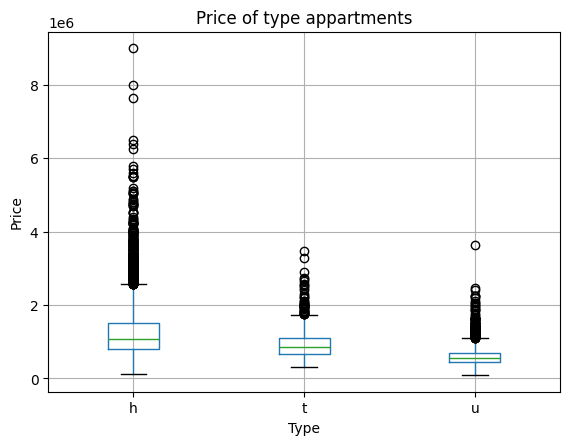

In [41]:
# 1) розподіл ціни: побудуйте гістограму Price
#    - використайте plt.hist(clean["Price"], bins=50)
#    - додайте підписи й plt.show()
# ...

# 2) (необов'язково) гістограма логарифма ціни для порівняння
#    - підказка: np.log10(clean["Price"])
# ...

# 3) ціна за типом житла: boxplot
#    - підказка: clean.boxplot(column="Price", by="Type")
clean.boxplot(column="Price", by="Type")
plt.suptitle("")
plt.title("Price of type appartments")
plt.ylabel("Price")
plt.show



In [46]:
# 4) кореляція числових ознак ІЗ ЦІНОЮ:
#    - візьміть лише числові стовпці: num = clean.select_dtypes("number")
#    - порахуйте num.corr()
#    - візьміть стовпець ["Price"], приберіть сам Price (.drop("Price"))
#    - відсортуйте за модулем: .sort_values(key=abs, ascending=False)
#    - надрукуйте і прочитайте: що найсильніше пов'язане з ціною?
num = clean.select_dtypes("number")
num.corr()['Price'].drop("Price").sort_values(key=abs, ascending=False).round(3)


before drop: (13580, 21)
ater drop: (6196, 21)


,Price
Rooms,0.534
BuildingArea,0.531
Bedroom2,0.515
Bathroom,0.504
YearBuilt,-0.305
Car,0.262
Lattitude,-0.214
Longtitude,0.212
Distance,-0.149
Postcode,0.126


In [53]:
df_drop = df.copy()
df_drop = df_drop.dropna()
print("before drop:", df.shape)
print("ater drop:", df_drop.shape)
num = df_drop.select_dtypes("number")
num.corr()['Price'].drop("Price").sort_values(key=abs, ascending=False).round(3)

before drop: (13580, 21)
ater drop: (6196, 21)


,Price
Rooms,0.534
BuildingArea,0.531
Bedroom2,0.515
Bathroom,0.504
YearBuilt,-0.305
Car,0.262
Lattitude,-0.214
Longtitude,0.212
Distance,-0.149
Postcode,0.126


In [ ]:
# 5) пошук майже-дублікатів: подивіться на повну матрицю кореляцій
#    - num.corr() (можна .round(2))
#    - знайдіть пари з дуже високим зв'язком (наприклад, Rooms і Bedroom2)
# ...

In [52]:
fe = clean.copy()

# 1) частини дати продажу
#    - рік: fe["sale_year"] = fe["Date"].dt.year
#    - місяць: за аналогією дістаньте .dt.month
fe["sale_year"] = fe["Date"].dt.year
fe["sale_month"] = fe["Date"].dt.month

# 2) вік будинку на момент продажу
#    - це рік продажу мінус рік побудови (YearBuilt)
#    - підстрахуйтесь: якщо вийшло від'ємне число, замініть на np.nan
fe['age'] = fe["sale_year"] - fe["YearBuilt"]
fe.loc[fe['age'] < 0, 'age'] = np.nan

# 3) прапорці наявності (пропуск як сигнал)
#    - для BuildingArea: fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
#    - зробіть так само has_yearbuilt для YearBuilt
fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
fe["has_yearbuilt"] = fe["YearBuilt"].notna().astype(int)

# 4) частотне кодування району Suburb
#    - підказка: fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())
fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())

# 5) приберіть зайве:
#    - дубль ознаки (наприклад, Bedroom2, бо схожий на Rooms)
#    - надто розріджені стовпці й текст, який не кодуєте (Address, SellerG, Suburb тощо)
#    - використайте fe.drop(columns=[...])
drop_cols = ['Bedroom2', 'Address',  'Suburb','Postcode', 'Date']
fe = fe.drop(columns=drop_cols)

In [47]:
clean.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')